w= [ 0.07630829  0.47707431  0.07630829 -1.11885613] [0.77991879 0.77991879 0.9398229  0.13408568] [ 0.43840923  0.83917525  0.43840923 -0.75675518] [0.72346518 0.72346518 0.88336929 0.07763206]
w2,w3= 0.9779895119966027 0.5384958704104337
b1,b2= [-1.25363377  1.57241755  1.43796631 -0.84099753] [-5.65810766  3.94460862  3.91120317 -5.56442548]


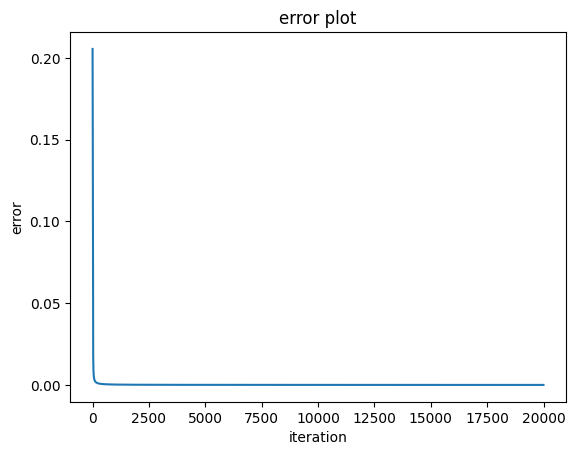

In [5]:
import numpy as np
import matplotlib.pyplot as plt
# Multiple samples
x1=np.array([0,1,0,1])
x2=np.array([0,0,1,1])
y=[0,1,1,0] # target
# Single Sample
# x1=np.array([0])
# x2=np.array([0])
# y=[0] # target
earray=[]
itra=[]
np.random.seed(7)
w00=np.random.rand() #weights for hidden layer
w01=np.random.rand() #weights for hidden layer
w10=np.random.rand() #weights for hidden layer
w11=np.random.rand() #weights for hidden layer
b1=1.0   #bias for hidden layer
w2=np.random.rand()  #weights for outputlayer
w3=np.random.rand()  #weights for output layer
b2=1.0   #bias for output layer
iterations=20000
for itr in range(iterations):

    # forward propagation, input layer to hidden layer
    z1=w00*x1+w01*x2+b1  # hidden layer z1
    z2=w10*x1+w11*x2+b1  # hidden layer z2
    h1=1/(1+np.exp(-z1)) # hidden layer h1
    h2=1/(1+np.exp(-z2)) # hidden layer h2
    # forward propagation
    # hidden layer to output layer
    zout=w2*h1+w3*h2+b2  # output  layer z
    o=1/(1+np.exp(-zout))# output  layer output o
    # Back propagation
    # output to hidden layer
    # gradient determination
    e=0.5*np.mean((o-y)*(o-y)) # simple error
    de_do=o-y
    do_dzout=o*(1-o)
    dzout_dw2=h1
    dzout_dw3=h2
    dzout_db2=1
    #de_dw2
    de_dw2=de_do*do_dzout*dzout_dw2
    #de_dw3
    de_dw3=de_do*do_dzout*dzout_dw3
    #de_db2
    de_db2=de_do*do_dzout*dzout_db2

    # hidden layer to input layer
    # gradient determination
    dzout_dh1=w2
    dh1_dz1=h1*(1-h1)
    dzout_dh2=w3
    dh2_dz2=h2*(1-h2)
    dz1_dw00=x1
    dz2_dw01=x2
    dz1_dw10=x1
    dz2_dw11=x2
    dz1_db1=1
    dz2_db1=1

    #de_dw00
    de_dw00=de_do*do_dzout*dzout_dh1*dh1_dz1*dz1_dw00
    #de_dw01
    de_dw01=de_do*do_dzout*dzout_dh2*dh2_dz2*dz2_dw01
    #de_dw10
    de_dw10=de_do*do_dzout*dzout_dh1*dh1_dz1*dz1_dw10
    #de_dw11
    de_dw11=de_do*do_dzout*dzout_dh2*dh2_dz2*dz2_dw11
    #de_db1
    de_db1=de_do*do_dzout*dzout_dh1*dh1_dz1*dz1_db1+de_do*do_dzout*dzout_dh2*dh2_dz2*dz2_db1

    #Updates
    w00-=de_dw00
    w01-=de_dw01
    w10-=de_dw10
    w11-=de_dw11
    b1-=de_db1
    b2-=de_db2
    earray.append(np.mean(e))
    itra.append(itr)
plt.ylabel("error")
plt.xlabel("iteration")
plt.title("error plot")
plt.plot(itra,earray)
print("w=",w00,w01,w10,w11)
print("w2,w3=",w2,w3)
print("b1,b2=",b1,b2)

In [6]:
# Multiple samples test
x1=np.array([0,1,0,1])
x2=np.array([0,0,1,1])
# Single sample test
# x1=np.array([0])
# x2=np.array([0])
z1=w00*x1+w01*x2+b1  # hidden layer z1
z2=w10*x1+w11*x2+b1  # hidden layer z2
h1=1/(1+np.exp(-z1)) # hidden layer h1
h2=1/(1+np.exp(-z2)) # hidden layer h2
# forward propagation
# hidden layer to output layer
zout=w2*h1+w3*h2+b2  # output  layer z
o=1/(1+np.exp(-zout))# output  layer output o
# print("o=",np.round(o))
# Print expected vs actual output for each sample
print("\nResults for each sample:")
for i in range(len(y)):
    expected = y[i]
    actual = int(round(o[i]))
    print(f"Sample {i+1} - Expected: {expected}, Actual: {actual}")




Results for each sample:
Sample 1 - Expected: 0, Actual: 0
Sample 2 - Expected: 1, Actual: 1
Sample 3 - Expected: 1, Actual: 1
Sample 4 - Expected: 0, Actual: 0
